# Chronos-2 Quality Net — Results, prediction_length=4, context_length=768 (2026-08-19)

`train/finetune_chronos2.py --prediction-length 4 --context-length 768`, `eval/backtest.py
--context-length 768`로 실행한 결과입니다. 지금까지 테스트한 context_length(24/73/128/168/256/384/512)는
전부 512 이하였는데, **이 노트북이 512보다 큰 값을 테스트한 첫 실험**입니다 — 512가 실제 최적점인지,
아니면 그동안 시도한 값 중 제일 컸을 뿐인지 확인하기 위함입니다.

`results_context512.ipynb`, `results_context384.ipynb`와 나란히 열어서 비교하면 됩니다.

context_length는 파인튜닝 여부와 무관하게 추론 시 모델에 들어가는 입력 길이 자체를 바꾸는 값이라,
**zero-shot도 `--context-length 768`으로 새로 평가했습니다**.

이 노트북은 GPU를 다시 쓰지 않습니다 — `eval/backtest_*_predlen4_ctx768_*.csv` 결과 파일만 읽습니다.
`eval/backtest.py`의 `predict_df` 호출은 여전히 `prediction_length=1`로 하드코딩되어 있어(평가 방식은
다른 context 실험들과 동일), 학습 시 held-out 구간(4)과 평가 시 예측 구간(1)이 다른 것은 의도된
설계입니다 — 자세한 이유는 `results_context512.ipynb` 및 `EXPERIMENT_LOG.md` 참고.

비교 대상 4가지:
- **Naive baseline**: 직전 실측값을 그대로 예측값으로 사용
- **Zero-shot**: `amazon/chronos-2` 사전학습 가중치, 파인튜닝 없음, `--context-length 768`으로 평가
- **LoRA**: `--prediction-length 4 --context-length 768`로 학습 (`checkpoints/{target}_predlen4_ctx768/final`)
- **Full fine-tuning**: `--prediction-length 4 --context-length 768`, `learning_rate=1e-6`
  (`checkpoints/{target}_full_predlen4_ctx768/final`)

In [1]:
import sys
import os
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib

plt.rcParams['font.family'] = 'Malgun Gothic'  # Windows 한글 폰트
matplotlib.rcParams['axes.unicode_minus'] = False

ROOT = Path.cwd()
if not (ROOT / "config.py").exists():
    raise RuntimeError(
        f"config.py를 {ROOT} 에서 찾지 못했습니다. Jupyter를 chronos_quality_net 폴더에서 실행하거나, "
        "이 노트북을 그 폴더로 옮겨서 다시 여세요."
    )
sys.path.insert(0, str(ROOT))
import config as cfg

TARGETS = cfg.TARGET_COLS  # ["blaine", "residue"]
print("targets:", TARGETS)
print("spec ranges:", cfg.SPEC_RANGES)

METHOD_TAGS = {
    "zero-shot": "predlen4_ctx768_zeroshot",
    "LoRA": "predlen4_ctx768_lora",
    "Full fine-tuning": "predlen4_ctx768_full",
}
METHODS = list(METHOD_TAGS.keys())

targets: ['blaine', 'residue']
spec ranges: {'blaine': (3700.0, 3900.0), 'residue': (7.0, 9.0)}


## 1. 결과 파일 불러오기

In [2]:
EVAL_DIR = ROOT / "eval"

results = {}
for target in TARGETS:
    results[target] = {}
    for method, tag in METHOD_TAGS.items():
        p = EVAL_DIR / f"backtest_{target}_{tag}.csv"
        if p.exists():
            results[target][method] = pd.read_csv(p, parse_dates=["timestamp"])
        else:
            print(f"[missing] {p}")

for target in TARGETS:
    for method in METHODS:
        df = results[target].get(method)
        print(target, method, "->", None if df is None else f"{len(df)} rows")

blaine zero-shot -> 1007 rows
blaine LoRA -> 1007 rows
blaine Full fine-tuning -> 1007 rows
residue zero-shot -> 979 rows
residue LoRA -> 979 rows
residue Full fine-tuning -> 979 rows


## 2. 요약 지표 (MAE / RMSE / R² / Spec 정확도 / 80% 구간 커버리지)

In [3]:
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score, confusion_matrix


def categorize(values, lo, hi):
    return np.where((values >= lo) & (values <= hi), "IN_SPEC", "OUT_OF_SPEC")


def compute_metrics(df: pd.DataFrame, target: str, pred_col: str) -> dict:
    lo, hi = cfg.SPEC_RANGES[target]
    mae = mean_absolute_error(df["actual"], df[pred_col])
    rmse = np.sqrt(mean_squared_error(df["actual"], df[pred_col]))
    r2 = r2_score(df["actual"], df[pred_col])
    actual_cls = categorize(df["actual"].to_numpy(), lo, hi)
    pred_cls = categorize(df[pred_col].to_numpy(), lo, hi)
    spec_accuracy = float((actual_cls == pred_cls).mean())
    row = {"MAE": mae, "RMSE": rmse, "R2": r2, "spec_accuracy": spec_accuracy, "n": len(df)}
    if pred_col == "pred" and "pred_q10" in df.columns and "pred_q90" in df.columns:
        row["interval_coverage"] = float(
            ((df["actual"] >= df["pred_q10"]) & (df["actual"] <= df["pred_q90"])).mean()
        )
    else:
        row["interval_coverage"] = np.nan
    return row


rows = []
for target in TARGETS:
    first_df = next((df for df in results[target].values() if df is not None), None)
    if first_df is not None:
        rows.append({"target": target, "method": "naive", **compute_metrics(first_df, target, "naive_pred")})
    for method in METHODS:
        df = results[target].get(method)
        if df is not None:
            rows.append({"target": target, "method": method, **compute_metrics(df, target, "pred")})

summary = pd.DataFrame(rows).set_index(["target", "method"])
summary.round(4)

MAE     RMSE      R2  spec_accuracy     n  \
target  method                                                            
blaine  naive             63.2075  92.9357  0.3908         0.7259  1007   
        zero-shot         66.1287  90.3687  0.4240         0.7061  1007   
        LoRA              65.7595  89.4121  0.4362         0.7061  1007   
        Full fine-tuning  64.3117  87.7136  0.4574         0.7200  1007   
residue naive              0.4150   0.6203  0.8091         0.8131   979   
        zero-shot          0.4338   0.6034  0.8194         0.7967   979   
        LoRA               0.4324   0.5953  0.8242         0.8049   979   
        Full fine-tuning   0.4267   0.5847  0.8304         0.8039   979   

                          interval_coverage  
target  method                               
blaine  naive                           NaN  
        zero-shot                    0.4022  
        LoRA                         0.4369  
        Full fine-tuning             0.4608  
residue naive                           NaN  
        zero-shot                    0.4025  
        LoRA                         0.4566  
        Full fine-tuning             0.5281

## 3. 방식별 비교 막대그래프 (MAE, RMSE, Spec 정확도)

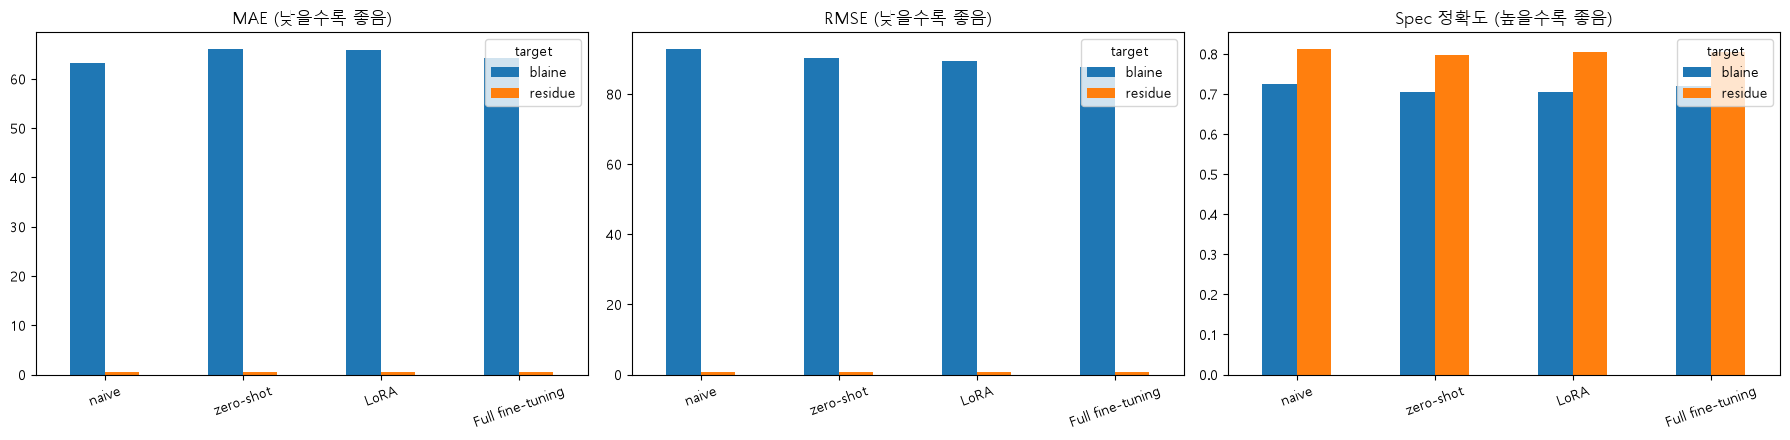

In [4]:
method_order = ["naive"] + METHODS
fig, axes = plt.subplots(1, 3, figsize=(18, 4.5))

metrics = ["MAE", "RMSE", "spec_accuracy"]
titles = ["MAE (낮을수록 좋음)", "RMSE (낮을수록 좋음)", "Spec 정확도 (높을수록 좋음)"]
for ax, metric, title in zip(axes, metrics, titles):
    plot_df = summary[metric].unstack("target").reindex(method_order)
    plot_df.plot(kind="bar", ax=ax)
    ax.set_title(title)
    ax.set_xlabel("")
    ax.legend(title="target")
    ax.tick_params(axis="x", rotation=20)

plt.tight_layout()
plt.show()

## 4. 실제값 vs 예측값 산점도 (naive / zero-shot / LoRA / full)

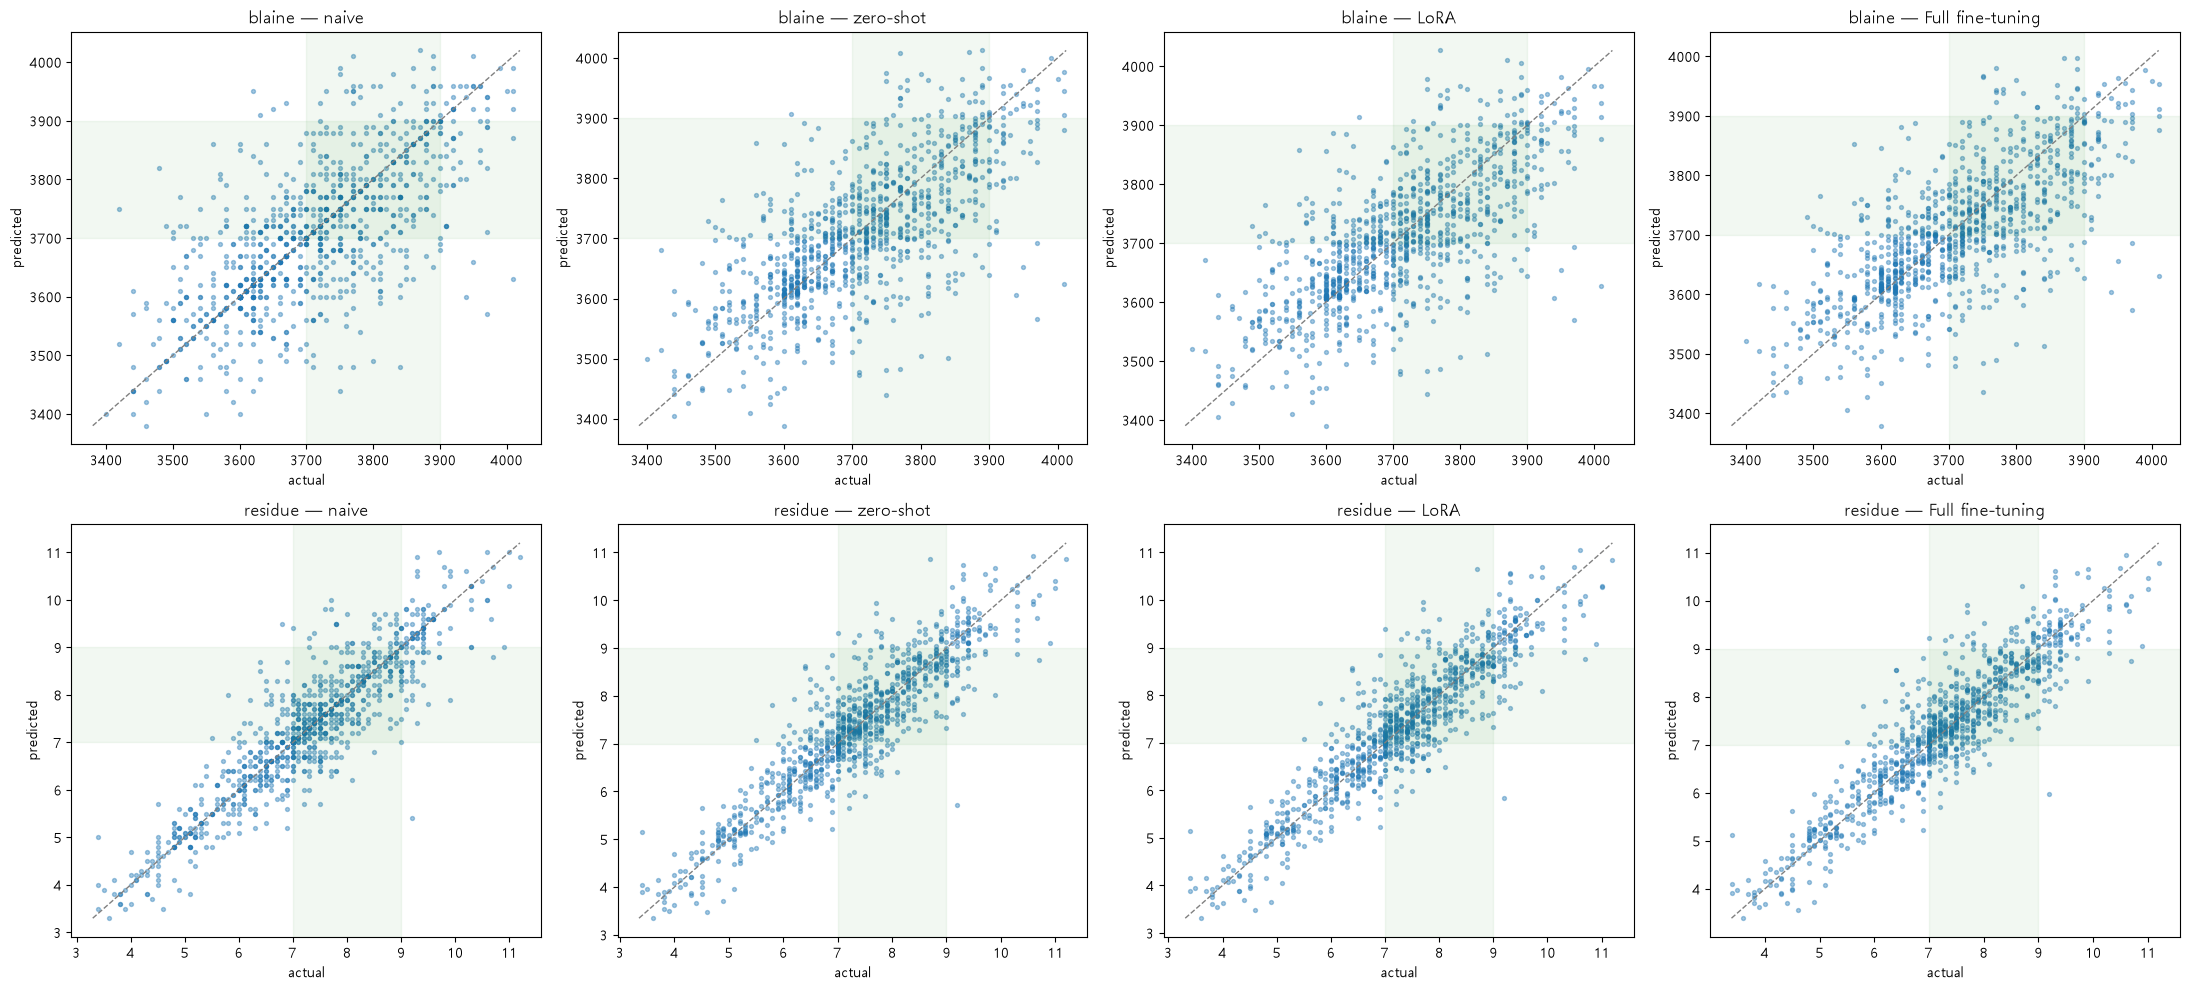

In [5]:
fig, axes = plt.subplots(len(TARGETS), 1 + len(METHODS), figsize=(5.5 * (1 + len(METHODS)), 5 * len(TARGETS)))
if len(TARGETS) == 1:
    axes = axes[None, :]

for row, target in enumerate(TARGETS):
    lo, hi = cfg.SPEC_RANGES[target]
    first_df = next((df for df in results[target].values() if df is not None), None)
    cols = [("naive", "naive_pred", first_df)] + [(m, "pred", results[target].get(m)) for m in METHODS]
    for col_idx, (label, pred_col, df) in enumerate(cols):
        ax = axes[row, col_idx]
        if df is None:
            ax.set_visible(False)
            continue
        ax.scatter(df["actual"], df[pred_col], s=8, alpha=0.4)
        lims = [min(df["actual"].min(), df[pred_col].min()), max(df["actual"].max(), df[pred_col].max())]
        ax.plot(lims, lims, color="gray", linestyle="--", linewidth=1)
        ax.axvspan(lo, hi, color="green", alpha=0.05)
        ax.axhspan(lo, hi, color="green", alpha=0.05)
        ax.set_title(f"{target} — {label}")
        ax.set_xlabel("actual")
        ax.set_ylabel("predicted")

plt.tight_layout()
plt.show()

## 5. 시계열: 실제값 vs 예측 + 80% 예측구간 (full fine-tuning 모델, 호기별)

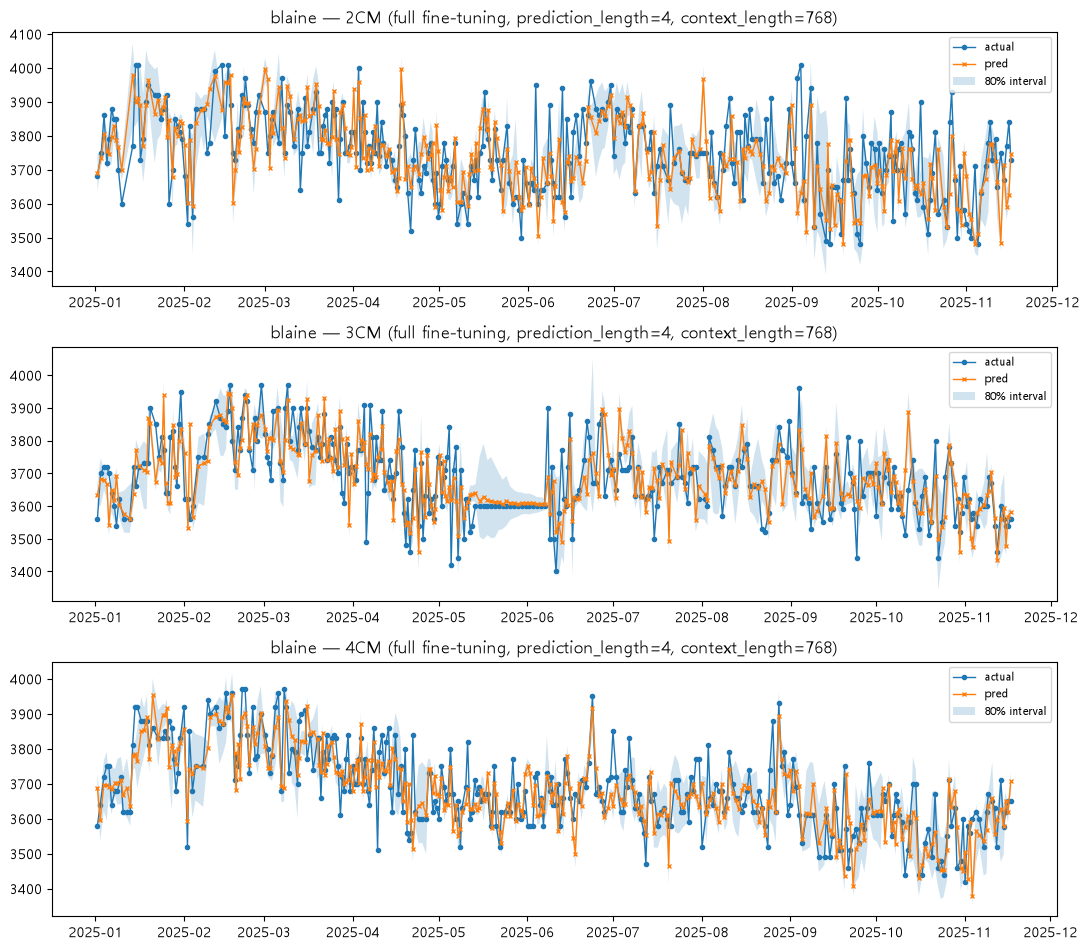

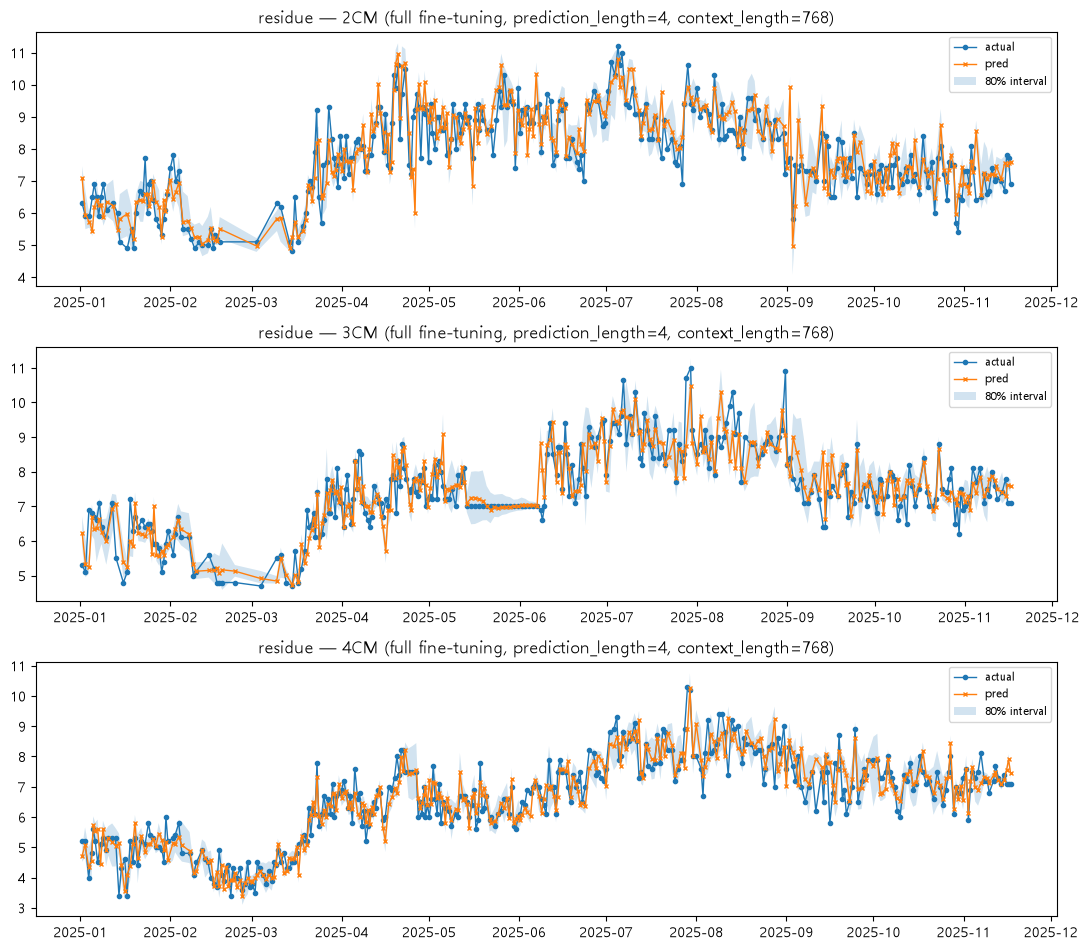

In [6]:
for target in TARGETS:
    df = results[target].get("Full fine-tuning")
    if df is None:
        continue
    item_ids = sorted(df["item_id"].unique())
    fig, axes = plt.subplots(len(item_ids), 1, figsize=(11, 3.2 * len(item_ids)), sharex=False)
    if len(item_ids) == 1:
        axes = [axes]
    for ax, item_id in zip(axes, item_ids):
        g = df[df["item_id"] == item_id].sort_values("timestamp")
        ax.plot(g["timestamp"], g["actual"], label="actual", marker="o", markersize=3, linewidth=1)
        ax.plot(g["timestamp"], g["pred"], label="pred", marker="x", markersize=3, linewidth=1)
        ax.fill_between(g["timestamp"], g["pred_q10"], g["pred_q90"], alpha=0.2, label="80% interval")
        ax.set_title(f"{target} — {item_id} (full fine-tuning, prediction_length=4, context_length=768)")
        ax.legend(loc="upper right", fontsize=8)
    plt.tight_layout()
    plt.show()

## 6. Confusion Matrix (Spec-in / Spec-out)

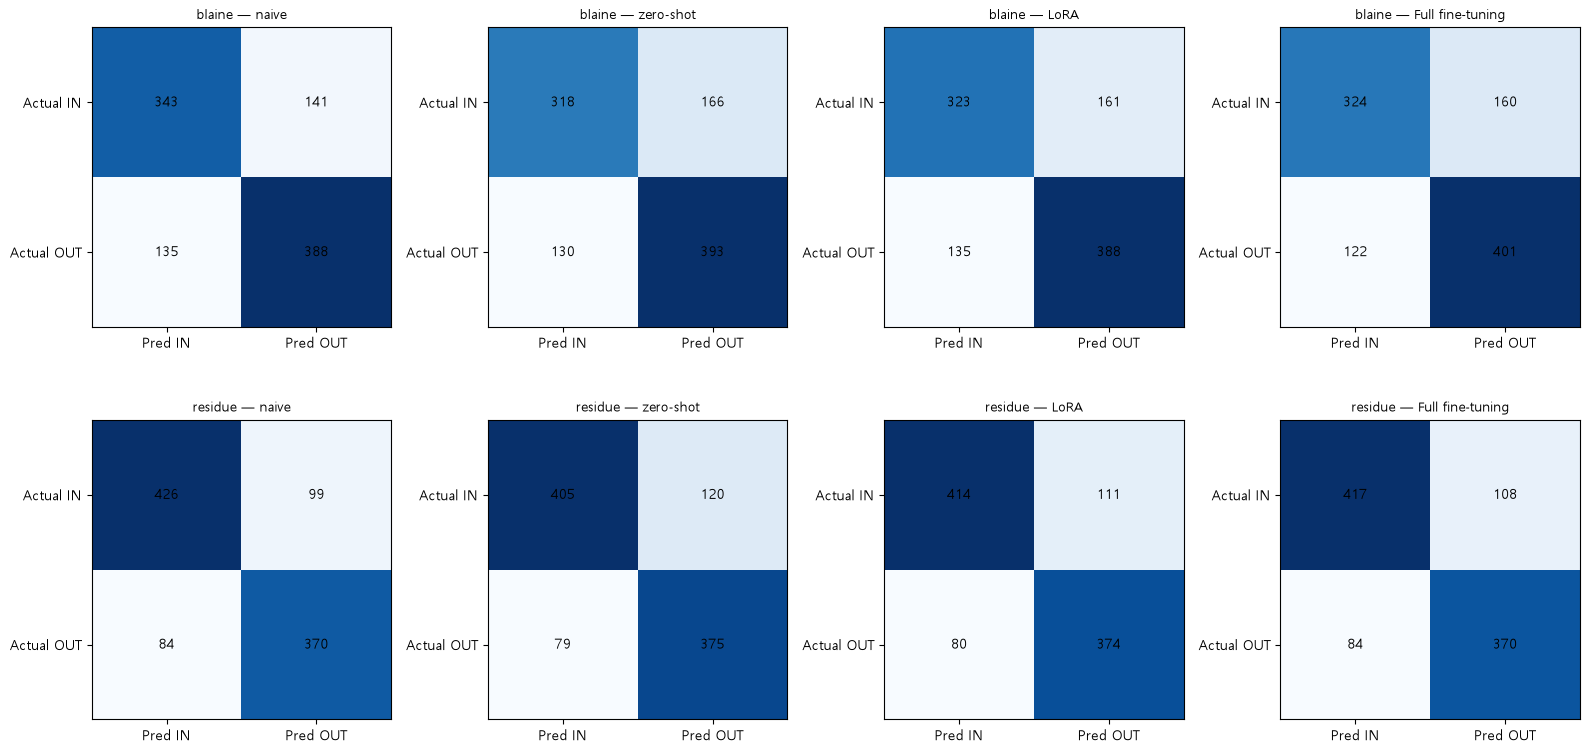

In [7]:
def plot_cm(ax, actual, pred, lo, hi, title):
    actual_cls = categorize(actual, lo, hi)
    pred_cls = categorize(pred, lo, hi)
    cm = confusion_matrix(actual_cls, pred_cls, labels=["IN_SPEC", "OUT_OF_SPEC"])
    ax.imshow(cm, cmap="Blues")
    for i in range(2):
        for j in range(2):
            ax.text(j, i, cm[i, j], ha="center", va="center")
    ax.set_xticks([0, 1]); ax.set_xticklabels(["Pred IN", "Pred OUT"])
    ax.set_yticks([0, 1]); ax.set_yticklabels(["Actual IN", "Actual OUT"])
    ax.set_title(title, fontsize=9)


fig, axes = plt.subplots(len(TARGETS), 1 + len(METHODS), figsize=(4 * (1 + len(METHODS)), 4 * len(TARGETS)))
if len(TARGETS) == 1:
    axes = axes[None, :]

for row, target in enumerate(TARGETS):
    lo, hi = cfg.SPEC_RANGES[target]
    first_df = next((df for df in results[target].values() if df is not None), None)
    cols = [("naive", "naive_pred", first_df)] + [(m, "pred", results[target].get(m)) for m in METHODS]
    for col_idx, (label, pred_col, df) in enumerate(cols):
        ax = axes[row, col_idx]
        if df is None:
            ax.set_visible(False)
            continue
        plot_cm(ax, df["actual"].to_numpy(), df[pred_col].to_numpy(), lo, hi, f"{target} — {label}")

plt.tight_layout()
plt.show()

## 7. 결론

- **context_length=768이 512보다 6개 조합 중 대부분에서 더 좋았습니다.** 512 이하 값(24~384)은 전부
  512보다 못했는데, **512를 넘어서자 처음으로 뚜렷한 개선이 나타났습니다.**
- **residue는 특히 명확합니다** — Full 기준 MAE 0.4298(ctx512) → **0.4267(ctx768, 신기록)**,
  R² 0.8295 → **0.8304(신기록)**, 80% 구간 커버리지 51.17% → **52.81%(신기록)**. zero-shot·LoRA도
  MAE·R²·spec 정확도·커버리지 거의 전부 개선됐습니다(유일하게 Full의 spec 정확도만 81.10%→80.39%로 소폭 하락).
- **blaine도 대체로 개선**됩니다 — zero-shot MAE 66.48→66.13, LoRA MAE 66.31→65.76(둘 다 개선), Full은
  R² 0.4550→**0.4574(신기록)**, spec 정확도 71.00%→**72.00%(신기록)**로 개선됐지만 MAE만 64.18→64.31로
  아주 근소하게 나빠졌습니다(0.13 차이, 사실상 오차 범위).
- **80% 구간 커버리지는 엇갈립니다** — residue는 뚜렷이 개선(신기록)되는 반면 blaine은 zero-shot·Full에서
  소폭 하락(coverage가 유일하게 나빠진 지표).
- **GPU 메모리/속도 문제 없이 정상 완료**됐습니다 (LoRA 학습 약 5.2 it/s, OOM 없음) — 768까지는 여유가 있는 것으로 보입니다.
- 종합하면 **"512가 최적점"이라는 이전 결론은 틀렸던 것으로 보입니다** — 최소 768까지는 컨텍스트를 늘릴수록
  계속 좋아지고 있어서, 진짜 꼭대기를 찾으려면 **1024 이상도 테스트해볼 가치가 있습니다.**

다른 context_length 결과는 `results_context512.ipynb`, `results_context384.ipynb`,
`results_context256.ipynb`, `results_context168.ipynb`, `results_context128.ipynb`,
`results_context73.ipynb`, `results_context24.ipynb`(prediction_length=1 기준) 참고.